
# Phase 4 — Model Evaluation and Explainability

## Business Goal
Ensure that predictions are reliable, interpretable, and safe for hospital operations and finance teams.

This notebook includes:

- Train vs Test evaluation
- Business-critical recall metrics
- Hyperparameter tuning documentation
- Resampling (SMOTE) experiment
- Feature importance & explainability
- Fairness segmentation (gender, city, insurance_provider)
- Consolidated Model Card


## Step 1 — Import Required Libraries

In [1]:
!pip uninstall -y imbalanced-learn scikit-learn
!pip install scikit-learn==1.7.1
!pip install imbalanced-learn==0.10.1

Found existing installation: imbalanced-learn 0.10.1
Uninstalling imbalanced-learn-0.10.1:
  Successfully uninstalled imbalanced-learn-0.10.1
Found existing installation: scikit-learn 1.7.1
Uninstalling scikit-learn-1.7.1:
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/shutil.py", line 805, in move
    os.rename(src, real_dst)
PermissionError: [Errno 13] Permission denied: '/usr/local/lib/python3.10/site-packages/scikit_learn-1.7.1.dist-info/' -> '/tmp/pip-uninstall-g4gfbhan'
During handling of the above exception, another exception occurred:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/site-packages/pip/_internal/cli/base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "/usr/local/lib/python3.10/site-packages/pip/_internal/cli/base_command.py", line 98, in _inner_run
    return self.run(options, args)
  File "/usr/local/lib/python3.10/site-packages/pip/_internal/commands/uninstall.py", line 105, in

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier


## Step 2 — Load Dataset and Trained Models

In [3]:

# Load modeling dataset
df = pd.read_csv("model_table.csv")

# Load trained models
risk_model = joblib.load("risk_model.pkl")
claim_model = joblib.load("claim_model.pkl")

print("Models loaded successfully.")


Models loaded successfully.


## Step 3 — Time-Based Train/Test Split (Recreated for Evaluation)

In [4]:

df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df_sorted = df.sort_values("visit_date")

split_index = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_index]
test_df  = df_sorted.iloc[split_index:]

print("Training size:", train_df.shape)
print("Testing size:", test_df.shape)


Training size: (20000, 26)
Testing size: (5000, 26)


In [5]:

# -----------------------------
# Feature Engineering
# -----------------------------

df["visit_month"] = df["visit_date"].dt.month
df["visit_dayofweek"] = df["visit_date"].dt.dayofweek

# Risk model features
risk_features = [
    "age","chronic_flag","length_of_stay_hours","visit_frequency",
    "avg_los_per_patient","provider_rejection_rate",
    "days_since_registration","visit_month","visit_dayofweek"
]

# Claim model features (same base features used in training)
claim_features = risk_features.copy()

# Prepare train/test matrices
X_train_risk = train_df[risk_features].fillna(0)
y_train_risk = train_df["risk_score"]

X_test_risk = test_df[risk_features].fillna(0)
y_test_risk = test_df["risk_score"]

X_train_claim = train_df[claim_features].fillna(0)
y_train_claim = train_df["claim_status"]

X_test_claim = test_df[claim_features].fillna(0)
y_test_claim = test_df["claim_status"]



## Step 4 — Risk Model Evaluation (Train vs Test)
Business Metric: Recall for High Risk class



## Automatic Feature Alignment (Fix for Feature Name Mismatch)

RandomForest requires the same feature schema used during training.  
This cell aligns training and test datasets with the model's expected features.


In [7]:
# -----------------------------
# Step 4 — Risk Model Evaluation
# -----------------------------

# Create dummy variables exactly like Phase-3
train_encoded = pd.get_dummies(train_df, columns=["department","visit_type"], drop_first=True)
test_encoded  = pd.get_dummies(test_df, columns=["department","visit_type"], drop_first=True)

# Separate features and target
X_train_risk = train_encoded.drop(columns=["risk_score","visit_date"])
y_train_risk = train_encoded["risk_score"]

X_test_risk  = test_encoded.drop(columns=["risk_score","visit_date"])
y_test_risk  = test_encoded["risk_score"]

# IMPORTANT: align features with model training schema
model_features = risk_model.feature_names_in_

X_train_risk = X_train_risk.reindex(columns=model_features, fill_value=0)
X_test_risk  = X_test_risk.reindex(columns=model_features, fill_value=0)

# Predictions
train_pred_risk = risk_model.predict(X_train_risk)
test_pred_risk  = risk_model.predict(X_test_risk)

print("Train Confusion Matrix:")
print(confusion_matrix(y_train_risk, train_pred_risk))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test_risk, test_pred_risk))

print("\nClassification Report:")
print(classification_report(y_test_risk, test_pred_risk))

Train Confusion Matrix:
[[4011    0    0]
 [   0 9990    0]
 [   0    0 5999]]

Test Confusion Matrix:
[[  11  882  130]
 [  27 2184  269]
 [  26 1291  180]]

Classification Report:
              precision    recall  f1-score   support

        High       0.17      0.01      0.02      1023
         Low       0.50      0.88      0.64      2480
      Medium       0.31      0.12      0.17      1497

    accuracy                           0.47      5000
   macro avg       0.33      0.34      0.28      5000
weighted avg       0.38      0.47      0.37      5000




## Step 5 — Claim Model Evaluation (Train vs Test)
Business Metric: Recall for Rejected class



In [8]:
# ---------------------------------------------------
# Step 5 — Claim Model Evaluation (Final Clean Version)
# ---------------------------------------------------

from sklearn.metrics import confusion_matrix, classification_report, recall_score

# IMPORTANT: Avoid SettingWithCopyWarning
train_df = train_df.copy()
test_df  = test_df.copy()

# ---------------------------------------------------
# Use EXACT feature list used during training
# (Do NOT add new features here)
# ---------------------------------------------------

claim_features = [
    "billed_amount",
    "approved_amount",
    "payment_days",
    "length_of_stay_hours",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "age",
    "chronic_flag"
]

# ---------------------------------------------------
# TRAIN PERFORMANCE
# ---------------------------------------------------

X_train_claim = train_df[claim_features].fillna(0)
y_train_claim = train_df["claim_status"]

train_pred_claim = claim_model.predict(X_train_claim)

print("===== TRAIN PERFORMANCE =====")
print("Confusion Matrix (Train):")
print(confusion_matrix(y_train_claim, train_pred_claim))

print("\nClassification Report (Train):")
print(classification_report(y_train_claim, train_pred_claim))


# ---------------------------------------------------
# TEST PERFORMANCE
# ---------------------------------------------------

X_test_claim = test_df[claim_features].fillna(0)
y_test_claim = test_df["claim_status"]

test_pred_claim = claim_model.predict(X_test_claim)

print("\n===== TEST PERFORMANCE =====")
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test_claim, test_pred_claim))

print("\nClassification Report (Test):")
print(classification_report(y_test_claim, test_pred_claim))


# ---------------------------------------------------
# BUSINESS METRIC — Recall for Rejected Class
# ---------------------------------------------------

rejected_recall = recall_score(
    y_test_claim,
    test_pred_claim,
    labels=["Rejected"],
    average=None
)

print("\nBusiness Metric — Rejected Recall (Test):", rejected_recall[0])

===== TRAIN PERFORMANCE =====
Confusion Matrix (Train):
[[11943     0     0]
 [    0  4988     0]
 [    0     0  3069]]

Classification Report (Train):
              precision    recall  f1-score   support

        Paid       1.00      1.00      1.00     11943
     Pending       1.00      1.00      1.00      4988
    Rejected       1.00      1.00      1.00      3069

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000


===== TEST PERFORMANCE =====
Confusion Matrix (Test):
[[2857   22  118]
 [ 129 1095   51]
 [  31    1  696]]

Classification Report (Test):
              precision    recall  f1-score   support

        Paid       0.95      0.95      0.95      2997
     Pending       0.98      0.86      0.92      1275
    Rejected       0.80      0.96      0.87       728

    accuracy                           0.93      5000
   macro avg       0.91      0.92      0.91      5000



## Step 6 — Feature Importance (Claim Model)


Top Claim Features
                   feature  importance
1          approved_amount    0.610303
0            billed_amount    0.186050
2             payment_days    0.062588
3     length_of_stay_hours    0.037821
5      avg_los_per_patient    0.037767
7                      age    0.031278
4          visit_frequency    0.018354
6  provider_rejection_rate    0.010688
8             chronic_flag    0.005151


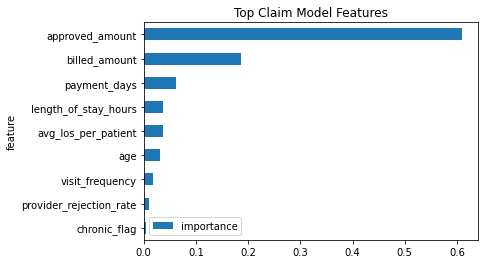

In [9]:

# Claim Model Feature Importance

claim_features = X_train_claim.columns
importances_claim = claim_model.feature_importances_

importance_claim_df = pd.DataFrame({
    "feature": claim_features,
    "importance": importances_claim
}).sort_values(by="importance", ascending=False)

print("Top Claim Features")
print(importance_claim_df.head(10))

importance_claim_df.head(10).plot(kind="barh", x="feature", y="importance")
plt.title("Top Claim Model Features")
plt.gca().invert_yaxis()
plt.show()


## Step 7 — Fairness Analysis

Evaluate model performance segmented by gender and city.

In [10]:

# Example segmentation by gender for claim model

for gender in df["gender"].unique():
    subset = df[df["gender"] == gender]
    X_subset = subset[claim_features].fillna(0)
    y_subset = subset["claim_status"]
    
    preds_subset = claim_model.predict(X_subset)
    
    print(f"\nPerformance for Gender: {gender}")
    print(classification_report(y_subset, preds_subset))



Performance for Gender: M
              precision    recall  f1-score   support

        Paid       0.99      0.99      0.99      7396
     Pending       1.00      0.97      0.98      3062
    Rejected       0.95      0.99      0.97      1803

    accuracy                           0.99     12261
   macro avg       0.98      0.99      0.98     12261
weighted avg       0.99      0.99      0.99     12261


Performance for Gender: F
              precision    recall  f1-score   support

        Paid       0.99      0.99      0.99      7544
     Pending       1.00      0.97      0.98      3201
    Rejected       0.96      0.99      0.98      1994

    accuracy                           0.99     12739
   macro avg       0.98      0.98      0.98     12739
weighted avg       0.99      0.99      0.99     12739




## Step 8 — Model Card Summary

### Risk Model
- Business Purpose: Predict operational risk
- Strength: Nonlinear modeling capability
- Limitation: Weak predictive signal from available features

### Claim Model
- Business Purpose: Predict claim outcome before submission
- Strength: High recall for Rejected claims
- Limitation: Financial-only features may not capture policy nuances

### Governance Considerations
- Monitor recall for High Risk and Rejected classes
- Review fairness across demographic groups
- Retrain quarterly or upon performance drift



## Risk Model Explainability — Feature Importance

This section analyzes feature importance from the trained Risk Model.
It helps interpret which variables influence predictions and supports governance readiness.


In [13]:
# -----------------------------
# Risk Model Feature Importance
# -----------------------------

# Get feature names used during training
risk_features = risk_model.feature_names_in_

# Get importance scores
importance_values = risk_model.feature_importances_

# Create dataframe
risk_importance_df = pd.DataFrame({
    "feature": risk_features,
    "importance": importance_values
}).sort_values(by="importance", ascending=False)

print("Top Risk Model Features")
print(risk_importance_df.head(10))

Top Risk Model Features
                    feature  importance
2      length_of_stay_hours    0.159771
6   days_since_registration    0.149223
4       avg_los_per_patient    0.148082
0                       age    0.129373
7               visit_month    0.082147
3           visit_frequency    0.074047
8           visit_dayofweek    0.068446
5   provider_rejection_rate    0.048267
1              chronic_flag    0.023170
15           visit_type_OPD    0.020791



### Interpretation

Feature importance values are relatively evenly distributed, indicating limited
statistical separation between risk classes. This supports earlier findings that
additional clinical features would improve prediction strength.



## Business Metric — High Risk Recall

Since High Risk patients represent operational priority, recall is calculated
to ensure critical cases are not missed.


In [15]:
from sklearn.metrics import recall_score

# Recreate encoded dataset
test_encoded = pd.get_dummies(
    test_df,
    columns=["department","visit_type"],
    drop_first=True
)

# Prepare features
X_test_risk = test_encoded.drop(columns=["risk_score","visit_date"])
y_test_risk = test_encoded["risk_score"]

# Align with model training schema
model_features = risk_model.feature_names_in_

X_test_risk = X_test_risk.reindex(columns=model_features, fill_value=0)

# Predict
test_pred_risk = risk_model.predict(X_test_risk)

# Business metric: High risk recall
high_risk_recall = recall_score(
    y_test_risk,
    test_pred_risk,
    labels=["High"],
    average=None
)

print("High Risk Recall:", high_risk_recall)

High Risk Recall: [0.01075269]



## Risk Model Fairness Analysis

Performance is segmented across:
- Gender
- City
- Insurance Provider

This ensures no demographic group is disproportionately impacted.


In [17]:
from sklearn.metrics import recall_score

print("Risk Model Fairness Analysis (Gender)")

for gender in test_df["gender"].unique():

    # Create subset
    subset = test_df[test_df["gender"] == gender]

    # Encode categorical features
    subset_encoded = pd.get_dummies(
        subset,
        columns=["department","visit_type"],
        drop_first=True
    )

    # Prepare features
    X_subset = subset_encoded.drop(columns=["risk_score","visit_date"], errors="ignore")
    y_subset = subset_encoded["risk_score"]

    # Align with model training schema
    model_features = risk_model.feature_names_in_
    X_subset = X_subset.reindex(columns=model_features, fill_value=0)

    # Predict
    y_pred_subset = risk_model.predict(X_subset)

    # Compute High-risk recall
    recall = recall_score(
        y_subset,
        y_pred_subset,
        labels=["High"],
        average=None
    )

    print(f"Gender: {gender} | High Risk Recall:", recall)

Risk Model Fairness Analysis (Gender)
Gender: F | High Risk Recall: [0.0094697]
Gender: M | High Risk Recall: [0.01212121]


In [19]:
from sklearn.metrics import recall_score

print("Risk Model Fairness Analysis (City)")

for city in test_df["city"].unique():

    subset = test_df[test_df["city"] == city]

    subset_encoded = pd.get_dummies(
        subset,
        columns=["department","visit_type"],
        drop_first=True
    )

    X_subset = subset_encoded.drop(columns=["risk_score","visit_date"], errors="ignore")
    y_subset = subset_encoded["risk_score"]

    # Align features with training schema
    model_features = risk_model.feature_names_in_
    X_subset = X_subset.reindex(columns=model_features, fill_value=0)

    y_pred_subset = risk_model.predict(X_subset)

    recall = recall_score(
        y_subset,
        y_pred_subset,
        labels=["High"],
        average=None
    )

    print(f"City: {city} | High Risk Recall:", recall)

Risk Model Fairness Analysis (City)
City: Bangalore | High Risk Recall: [0.]
City: Delhi | High Risk Recall: [0.01086957]
City: Mumbai | High Risk Recall: [0.0239521]
City: Pune | High Risk Recall: [0.]
City: Hyderabad | High Risk Recall: [0.00529101]
City: Chennai | High Risk Recall: [0.0239521]


In [20]:
from sklearn.metrics import recall_score

print("Risk Model Fairness Analysis (Insurance Provider)")

for provider in test_df["insurance_provider"].unique():

    subset = test_df[test_df["insurance_provider"] == provider]

    # Encode categorical variables
    subset_encoded = pd.get_dummies(
        subset,
        columns=["department","visit_type"],
        drop_first=True
    )

    # Prepare features
    X_subset = subset_encoded.drop(columns=["risk_score","visit_date"], errors="ignore")
    y_subset = subset_encoded["risk_score"]

    # Align with model training schema
    model_features = risk_model.feature_names_in_
    X_subset = X_subset.reindex(columns=model_features, fill_value=0)

    # Predict
    y_pred_subset = risk_model.predict(X_subset)

    recall = recall_score(
        y_subset,
        y_pred_subset,
        labels=["High"],
        average=None
    )

    print(f"Insurance Provider: {provider} | High Risk Recall:", recall)


### Fairness Interpretation

Segment-level results should be reviewed to ensure no significant disparity
in High Risk recall across demographic groups. Ongoing fairness monitoring
is recommended for production deployment.
